# Sensor-Based Driving Event Detection

**Dara Manohar | ML Intern Assignment**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/Daramanohar/Sensor-Based-Driving-Event-Detection/blob/main/ML_Intern_Assignment_Solution.ipynb)

I developed an end-to-end workflow for detecting driving events from smartphone
accelerometer, gyroscope, and GPS signals. The solution combines an interpretable
streaming detector with an XGBoost classifier and evaluates both at the event level.
All tables and figures in this notebook are generated from the supplied data.

## Reproducibility

I designed the notebook to run from top to bottom on a standard Colab CPU runtime as
well as a local Python environment. The setup resolves the repository, installs the
package, and fixes the random seed before executing the analysis. The generated CSV
and JSON files are retained as compact supporting artifacts.

## Assignment coverage

| Question | Work completed |
|---|---|
| **Q1: event identification** | interval labels, sensor interpretation, data validation, and visual analysis |
| **Q2: jerk and RMS** | mathematical derivation, numerical calculation, and multi-scale features |
| **Q3: imbalanced metrics** | precision, recall, F1, accuracy, and threshold trade-offs |
| **Q4: real-time detection** | causal GPS/IMU processing, hysteresis, merging, and GPS-gap testing |
| **Q5: model selection** | grouped validation, baseline comparison, XGBoost, and error analysis |
| **Additional work** | full-session replay, automated tests, and reproducible artifacts |

In [1]:
import os
import platform
import subprocess
import sys
import time
from pathlib import Path

REPOSITORY = "https://github.com/Daramanohar/Sensor-Based-Driving-Event-Detection.git"
PROJECT_NAME = "Sensor-Based-Driving-Event-Detection"
IN_COLAB = "google.colab" in sys.modules


if IN_COLAB:
    from google.colab import data_table

    # Static HTML tables remain visible in the downloaded notebook.
    data_table.disable_dataframe_formatter()

if (Path.cwd() / "config.yaml").exists():
    ROOT = Path.cwd().resolve()
elif IN_COLAB:
    ROOT = Path("/content") / PROJECT_NAME
    if not ROOT.exists():
        subprocess.run(["git", "clone", REPOSITORY, str(ROOT)], check=True)
    if not (ROOT / "config.yaml").exists():
        raise RuntimeError(f"Repository exists but is incomplete: {ROOT}")
    os.chdir(ROOT)
else:
    raise RuntimeError("Run this notebook from the repository root.")

install = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"],
    cwd=ROOT,
    text=True,
    capture_output=True,
)
if install.returncode != 0:
    print(install.stdout)
    print(install.stderr)
    raise RuntimeError("Package installation failed")

# Editable installs add a .pth file that a fresh Python process reads at startup.
# Add src explicitly so the current Colab kernel can import it without a restart.
SOURCE_ROOT = str(ROOT / "src")
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

try:
    import driving_events as _driving_events
except ModuleNotFoundError as error:
    raise RuntimeError(
        f"Package installation completed but import verification failed: {SOURCE_ROOT}"
    ) from error

print(f"Runtime: {'Google Colab' if IN_COLAB else 'local'}")
print(f"Repository root: {ROOT}")
print(f"Python: {sys.version.split()[0]} | Platform: {platform.platform()}")
print("Package installation complete")
print("Package import successful in the current kernel")

Runtime: local
Repository root: C:\Users\hp\Desktop\Sensor-Based Driving Event Detection
Python: 3.11.9 | Platform: Windows-10-10.0.26200-SP0
Package installation complete
Package import successful in the current kernel


### End-to-end execution

I regenerate the data profiles, rule-detector evaluation, GPS robustness results,
model comparison, feature importance, and full-session detections from the raw inputs.
I also record the package versions used for the run.

In [2]:
import hashlib
import json
from importlib.metadata import version

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import seaborn as sns

from driving_events.config import load_config
from driving_events.data import (
    label_samples,
    load_annotations,
    load_sensor_csv,
    profile_sensor_frame,
)
from driving_events.features import extract_feature_table, model_feature_columns
from driving_events.labeling import annotation_coverage
from driving_events.preprocessing import preprocess_sensor_frame
from run_pipeline import main as execute_pipeline

sns.set_theme(style="whitegrid", context="notebook")
started = time.perf_counter()
exit_code = execute_pipeline()
runtime_s = time.perf_counter() - started
assert exit_code == 0

versions = pd.DataFrame(
    {
        "package": ["numpy", "pandas", "scikit-learn", "xgboost", "scipy"],
        "version": [
            version("numpy"),
            version("pandas"),
            version("scikit-learn"),
            version("xgboost"),
            version("scipy"),
        ],
    }
)
print(f"Pipeline execution time: {runtime_s:.2f} seconds")
display(versions)

Pipeline completed
  Labeled sample rule macro-F1: 1.0000
  Best grouped-CV model: xgboost (macro-F1=0.7596)
  Full-session detected episodes: 89
  Results: C:\Users\hp\Desktop\Sensor-Based Driving Event Detection\results
Pipeline execution time: 8.28 seconds


,package,version
0,numpy,2.0.2
1,pandas,2.2.2
2,scikit-learn,1.7.1
3,xgboost,3.0.4
4,scipy,1.15.3


## Problem statement and solution architecture

The phone is fixed in portrait orientation and records inertial signals at 10 or
50 Hz, while GPS speed changes at a slower rate. I treat this as a time-series event
detection problem: the output should contain one class, onset, and end time for each
physical event rather than one prediction for every sensor row.

For the supplied mounting convention:

- `accel_y` is the vertical axis and contains the gravity baseline;
- `accel_z` is the longitudinal axis and separates acceleration from braking;
- `accel_x` is lateral and helps distinguish turns;
- gyroscope signals describe pitch, yaw, roll, and short vibration patterns.

My processing flow is:

```text
raw sensor samples
    -> schema and physical-limit validation
    -> causal filtering, gravity separation, and GPS age
    -> multi-scale time-window features
    -> interpretable scores or XGBoost probabilities
    -> duration, hysteresis, and temporal merging
    -> one interval per detected event
```

## Q1: Event identification, labeling, and data integrity

I first validate the two sensor sessions and then describe the short sample as
contiguous Stationary, Normal Driving, or target-event intervals. The labels are based
on manual inspection of the supplied signals and the assignment definitions. They are
useful for analyzing this session, but they are not an independent external test set.

### Input loading and provenance

I load both CSV files through the same validated schema and attach a session identifier.
File sizes and SHA-256 hashes make the exact inputs used in this run traceable.

In [3]:
config = load_config(ROOT / "config.yaml")
sample_rate = float(config["data"]["sample_rate_hz"])
full_rate = float(config["data"]["full_rate_hz"])

sample = load_sensor_csv(
    ROOT / config["data"]["sample_csv"],
    sample_rate,
    session_id="sample_10hz",
    physical_limits=config["data"]["physical_limits"],
)
full = load_sensor_csv(
    ROOT / config["data"]["full_csv"],
    full_rate,
    session_id="full_50hz",
    physical_limits=config["data"]["physical_limits"],
)
labels = load_annotations(ROOT / "data/sample_labels.csv", reviewed_only=True)
labeled = label_samples(sample, labels, require_complete_coverage=True)

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

input_manifest = pd.DataFrame(
    [
        {
            "file": path.relative_to(ROOT).as_posix(),
            "bytes": path.stat().st_size,
            "sha256": sha256(path),
        }
        for path in [
            ROOT / config["data"]["sample_csv"],
            ROOT / config["data"]["full_csv"],
            ROOT / "data/sample_labels.csv",
            ROOT / "config.yaml",
        ]
    ]
)
display(input_manifest)

,file,bytes,sha256
0,data/sample_sensor_data.csv,14725,dea4382107a3121ac6d27301579af89a967cd86267878c...
1,data/driving_session_30min_50Hz.csv,5382858,c40e488b767569b4fb3989491077897130c42bf6daa05e...
2,data/sample_labels.csv,2284,50e1e351c8fe07c93305d6e4600fe5c428d2a13546928c...
3,config.yaml,1650,799ca94451f7b3961268b68483517d894170a82e5f4eda...


### Data-quality summary

Before feature extraction, I check row counts, duration, missing values, exact
duplicates, physical-limit violations, GPS update intervals, and label coverage.

In [4]:
sample_profile = profile_sensor_frame(sample, sample_rate)
full_profile = profile_sensor_frame(full, full_rate)
coverage = annotation_coverage(sample, labeled)

quality = pd.DataFrame(
    [
        {
            "session": "labeled sample",
            "rows": sample_profile["rows"],
            "duration_s": sample_profile["duration_s"],
            "rate_hz": sample_profile["sample_rate_hz"],
            "missing_values": sum(sample_profile["missing_values"].values()),
            "duplicate_rows": sample_profile["duplicate_rows"],
            "invalid_rows": sample_profile["invalid_rows"],
            "gps_fixes": sample_profile["gps_fixes"],
            "max_gps_gap_s": sample_profile["gps_gap_s"]["max"],
        },
        {
            "session": "full drive",
            "rows": full_profile["rows"],
            "duration_s": full_profile["duration_s"],
            "rate_hz": full_profile["sample_rate_hz"],
            "missing_values": sum(full_profile["missing_values"].values()),
            "duplicate_rows": full_profile["duplicate_rows"],
            "invalid_rows": full_profile["invalid_rows"],
            "gps_fixes": full_profile["gps_fixes"],
            "max_gps_gap_s": full_profile["gps_gap_s"]["max"],
        },
    ]
)
checks = {
    "required rows loaded": len(sample) == 258 and len(full) == 90_000,
    "no missing sensor values": quality["missing_values"].sum() == 0,
    "no exact duplicate rows": quality["duplicate_rows"].sum() == 0,
    "no physical-limit violations": quality["invalid_rows"].sum() == 0,
    "sample labels cover every row": coverage["coverage"] == 1.0,
    "no overlapping label assignment": labeled["label"].notna().all(),
}
assert all(checks.values()), checks
display(quality)
display(pd.DataFrame({"check": checks.keys(), "status": ["PASS"] * len(checks)}))

,session,rows,duration_s,rate_hz,missing_values,duplicate_rows,invalid_rows,gps_fixes,max_gps_gap_s
0,labeled sample,258,25.8,10.0,0,0,0,26,1.0
1,full drive,90000,1800.0,50.0,0,0,0,1800,1.0


,check,status
0,required rows loaded,PASS
1,no missing sensor values,PASS
2,no exact duplicate rows,PASS
3,no physical-limit violations,PASS
4,sample labels cover every row,PASS
5,no overlapping label assignment,PASS


### Interval labels

The table lists the complete sequence of intervals, including Normal Driving between
target events. I include duration, severity, and a short signal-based interpretation.

In [5]:
label_evidence = labels[
    ["event_id", "start_time_s", "end_time_s", "label", "severity", "notes"]
].copy()
label_evidence["duration_s"] = (
    label_evidence["end_time_s"] - label_evidence["start_time_s"] + 1 / sample_rate
).round(2)
display(label_evidence)
display(
    labeled["label"]
    .value_counts()
    .rename_axis("label")
    .to_frame("labeled_samples")
)
print(
    "Label provenance: manual signal review using the assignment definitions. "
    "This is not an independent external test set."
)

,event_id,start_time_s,end_time_s,label,severity,notes,duration_s
0,sample_001,0.0,0.9,Stationary,na,GPS speed is zero; IMU is at baseline.,1.0
1,sample_002,1.0,1.6,Clutch Release,moderate,Brief multi-axis vibration without sustained l...,0.7
2,sample_003,1.7,3.8,Normal Driving,na,Smooth pull-away.,2.2
3,sample_004,3.9,4.5,Harsh Acceleration,strong,Sustained positive longitudinal acceleration w...,0.7
4,sample_005,4.6,8.3,Normal Driving,na,Cruise and a yaw/lateral turn; no harsh event.,3.8
5,sample_006,8.4,9.2,Harsh Braking,moderate,Sustained negative longitudinal acceleration w...,0.9
6,sample_007,9.3,10.4,Normal Driving,na,Recovery after braking.,1.2
7,sample_008,10.5,10.6,Pothole/Bump,strong,Large vertical spike/dip with pitch response.,0.2
8,sample_009,10.7,14.2,Normal Driving,na,Includes gentle deceleration to a stop; delibe...,3.6
9,sample_010,14.3,14.6,Clutch Release,weak,Short multi-axis vibration while nearly stopped.,0.4


,labeled_samples
label,
Normal Driving,203
Harsh Braking,16
Harsh Acceleration,13
Clutch Release,11
Stationary,10
Pothole/Bump,5


Label provenance: manual signal review using the assignment definitions. This is not an independent external test set.


### Sensor interpretation

I overlay the target intervals on longitudinal and vertical acceleration, pitch, yaw,
and GPS speed. This makes it possible to compare every label with its raw signal shape.

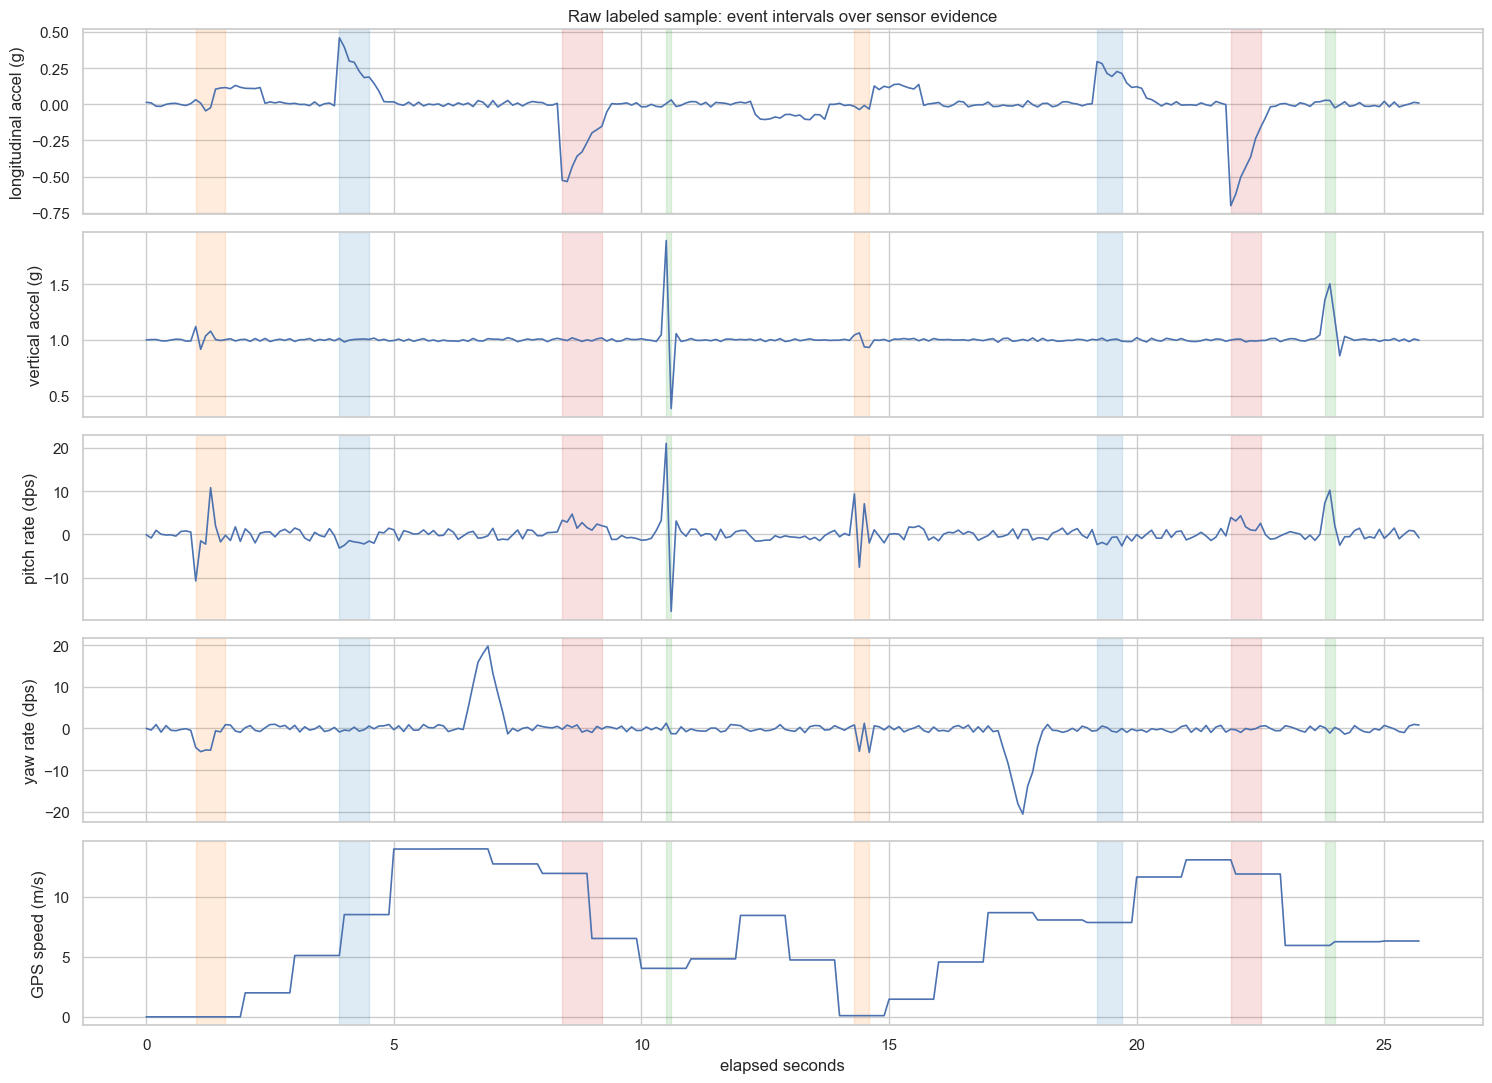

In [6]:
event_colors = {
    "Harsh Braking": "#d62728",
    "Harsh Acceleration": "#1f77b4",
    "Pothole/Bump": "#2ca02c",
    "Clutch Release": "#ff7f0e",
}
fig, axes = plt.subplots(5, 1, figsize=(15, 11), sharex=True)
series = [
    ("accel_z_g", "longitudinal accel (g)"),
    ("accel_y_g", "vertical accel (g)"),
    ("gyro_x_dps", "pitch rate (dps)"),
    ("gyro_y_dps", "yaw rate (dps)"),
    ("gps_speed_mps", "GPS speed (m/s)"),
]
for axis, (column, ylabel) in zip(axes, series, strict=True):
    axis.plot(sample["elapsed_s"], sample[column], linewidth=1.2)
    axis.set_ylabel(ylabel)
    for row in labels.itertuples(index=False):
        if row.label in event_colors:
            axis.axvspan(
                row.start_time_s,
                row.end_time_s,
                color=event_colors[row.label],
                alpha=0.14,
            )
axes[0].set_title("Raw labeled sample: event intervals over sensor evidence")
axes[-1].set_xlabel("elapsed seconds")
plt.tight_layout()
plt.show()

## Q2: Jerk, RMS, and causal feature engineering

At 10 Hz, the sample interval is \(\Delta t=0.1\) seconds. I calculate discrete
longitudinal jerk as

\[
j[n] = \frac{a_z[n]-a_z[n-1]}{\Delta t}.
\]

For a gyroscope window containing \(N\) values, I calculate

\[
RMS[n] = \sqrt{\frac{1}{N}\sum_{k=0}^{N-1}g[k]^2}.
\]

Jerk emphasizes abrupt longitudinal changes, while RMS summarizes sustained rotational
or vibration energy. For classification I extend these ideas into causal 0.25, 0.5, 1,
and 2-second windows.

### Numerical jerk and RMS calculation

I calculate the requested quantities directly from the sample rows so the units and
finite-difference convention are explicit.

In [7]:
braking_onset = sample.iloc[82:87][["timestamp", "accel_z_g"]].copy()
jerk_g_per_s = np.diff(braking_onset["accel_z_g"].to_numpy()) / 0.1
gyro_window = sample.loc[10:14, "gyro_z_dps"].to_numpy()
gyro_rms = np.sqrt(np.mean(gyro_window**2))
display(braking_onset)
print("Step jerk (g/s):", np.round(jerk_g_per_s, 3))
print(
    f"Average jerk: {jerk_g_per_s.mean():.4f} g/s "
    f"= {jerk_g_per_s.mean() * 9.81:.2f} m/s³"
)
print(f"Example five-sample gyro-z RMS: {gyro_rms:.4f} dps")

,timestamp,accel_z_g
82,15:08.2,-0.006
83,15:08.3,0.006
84,15:08.4,-0.526
85,15:08.5,-0.535
86,15:08.6,-0.433


Step jerk (g/s): [ 0.12 -5.32 -0.09  1.02]
Average jerk: -1.0675 g/s = -10.47 m/s³
Example five-sample gyro-z RMS: 5.6526 dps


### Multi-scale feature table

The feature set includes acceleration and gyroscope statistics, jerk, vector
magnitudes, robust quantiles, spectral ratios, duration fractions, GPS age, and signal
validity. I exclude labels, event identifiers, timestamps, and annotation metadata.
I also compare a prefix-only calculation with the same rows from the full sequence to
confirm that future samples do not affect earlier features.

In [8]:
processed = preprocess_sensor_frame(labeled, sample_rate, config)
features = extract_feature_table(processed, sample_rate, config)
feature_columns = model_feature_columns(features)

prefix = labeled.iloc[:180].copy()
prefix_processed = preprocess_sensor_frame(prefix, sample_rate, config)
prefix_features = extract_feature_table(prefix_processed, sample_rate, config)
aligned = prefix_features[["elapsed_s", *feature_columns]].merge(
    features[["elapsed_s", *feature_columns]],
    on="elapsed_s",
    suffixes=("_prefix", "_full"),
    validate="one_to_one",
)
differences = []
for name in feature_columns:
    left = aligned[f"{name}_prefix"].to_numpy(dtype=float)
    right = aligned[f"{name}_full"].to_numpy(dtype=float)
    differences.append(np.nanmax(np.abs(left - right)))
max_prefix_difference = float(np.nanmax(differences))

forbidden = {
    "label", "event_id", "review_status", "annotation_source",
    "notes", "timestamp", "session_id",
}
leakage_columns = sorted(forbidden.intersection(feature_columns))
feature_checks = {
    "125 curated model features": len(feature_columns) == 125,
    "no label/identity metadata in model inputs": not leakage_columns,
    "causal prefix invariance": max_prefix_difference < 1e-10,
    "all model feature values finite": np.isfinite(
        features[feature_columns].to_numpy(dtype=float)
    ).all(),
}
assert all(feature_checks.values()), feature_checks
display(
    pd.DataFrame(
        {
            "check": feature_checks.keys(),
            "status": ["PASS"] * len(feature_checks),
        }
    )
)
print(f"Maximum prefix/full feature difference: {max_prefix_difference:.3e}")
print(f"Feature table shape: {features.shape}")

,check,status
0,125 curated model features,PASS
1,no label/identity metadata in model inputs,PASS
2,causal prefix invariance,PASS
3,all model feature values finite,PASS


Maximum prefix/full feature difference: 0.000e+00
Feature table shape: (258, 427)


## Q3: Evaluation metrics for imbalanced events

For TP=144, FN=36, FP=212, and TN=9608, overall accuracy is dominated by the Normal
Driving class. I therefore calculate precision, recall, and F1 explicitly and compare
the result with an always-normal classifier. In practice, I would choose the operating
threshold on validation data using target-event recall and false positives per driving
hour.

### Metric calculation

The calculation below shows why a high accuracy value can coexist with weaker
event precision and why class-sensitive metrics are needed.

In [9]:
TP, FN, FP, TN = 144, 36, 212, 9608
precision = TP / (TP + FP)
recall = TP / (TP + FN)
metric_example = pd.Series(
    {
        "precision": precision,
        "recall": recall,
        "f1": 2 * precision * recall / (precision + recall),
        "accuracy": (TP + TN) / (TP + FN + FP + TN),
        "always-normal accuracy": (TN + FP) / (TP + FN + FP + TN),
    }
)
display(metric_example.round(4).to_frame("value"))
print(
    "Accuracy looks high even for an always-normal model; macro/class recall and "
    "false positives per hour are decision-relevant."
)

,value
precision,0.4045
recall,0.8000
f1,0.5373
accuracy,0.9752
always-normal accuracy,0.9820


Accuracy looks high even for an always-normal model; macro/class recall and false positives per hour are decision-relevant.


## Q4: Real-time GPS/IMU event detection

My streaming path is IMU-first. GPS contributes speed, speed change, age, and freshness,
but stale GPS never blocks strong inertial evidence. Class scores are passed through a
state machine with minimum duration, onset and offset hysteresis, optional maximum
duration, and short-gap merging.

All timing rules are expressed in seconds and converted using the sampling rate, so the
same implementation works at both 10 Hz and 50 Hz. The final output contains one
de-duplicated interval with confidence, severity, duration, and peak time.

### Interval matching

I pair each manually identified target interval with one detector output of the same
class and report onset and end-time differences.

In [10]:
summary = json.loads((ROOT / "results/summary.json").read_text(encoding="utf-8"))
detected_sample = pd.read_csv(ROOT / "results/sample_events.csv")
target_truth = labels.loc[
    labels["label"].isin(config["project"]["event_labels"]),
    ["start_time_s", "end_time_s", "label"],
].copy()
target_truth["occurrence"] = target_truth.groupby("label").cumcount() + 1
detected_sample["occurrence"] = detected_sample.groupby("label").cumcount() + 1
matched = target_truth.merge(
    detected_sample[
        [
            "start_time_s", "end_time_s", "label", "occurrence",
            "confidence", "severity", "event_id",
        ]
    ],
    on=["label", "occurrence"],
    suffixes=("_truth", "_detected"),
    validate="one_to_one",
)
matched["onset_error_s"] = (
    matched["start_time_s_detected"] - matched["start_time_s_truth"]
).round(3)
matched["end_error_s"] = (
    matched["end_time_s_detected"] - matched["end_time_s_truth"]
).round(3)
display(
    matched[
        [
            "label", "occurrence", "start_time_s_truth",
            "start_time_s_detected", "onset_error_s", "end_time_s_truth",
            "end_time_s_detected", "end_error_s", "confidence",
        ]
    ]
)

,label,occurrence,start_time_s_truth,start_time_s_detected,onset_error_s,end_time_s_truth,end_time_s_detected,end_error_s,confidence
0,Clutch Release,1,1.0,1.0,0.0,1.6,1.5,-0.1,0.778354
1,Harsh Acceleration,1,3.9,4.0,0.1,4.5,4.5,0.0,1.000000
2,Harsh Braking,1,8.4,8.5,0.1,9.2,9.1,-0.1,1.000000
3,Pothole/Bump,1,10.5,10.5,0.0,10.6,10.6,0.0,1.000000
4,Clutch Release,2,14.3,14.5,0.2,14.6,14.9,0.3,0.723648
5,Harsh Acceleration,2,19.2,19.3,0.1,19.7,19.7,0.0,0.772750
6,Harsh Braking,2,21.9,22.0,0.1,22.5,22.5,0.0,1.000000
7,Pothole/Bump,2,23.8,23.8,0.0,24.0,23.9,-0.1,0.861388


### Event-level evaluation

I evaluate unique event intervals rather than individual sensor rows. Duplicate
detections remain false positives, and onset latency is reported alongside per-class
precision, recall, and F1.

In [11]:
rule_metrics = summary["rule_detector_on_labeled_sample"]
per_class_events = pd.DataFrame(rule_metrics["per_class"]).T
event_checks = {
    "eight target intervals present": rule_metrics["reviewed_true_events"] == 8,
    "eight intervals detected": rule_metrics["predicted_events"] == 8,
    "one-to-one matches": rule_metrics["matched_events"] == 8,
    "no duplicate event IDs": detected_sample["event_id"].is_unique,
    "no non-positive durations": (detected_sample["duration_s"] > 0).all(),
    "zero labeled-sample false positives": (
        rule_metrics["false_positives_per_hour"] == 0
    ),
}
assert all(event_checks.values()), event_checks
display(per_class_events)
display(pd.DataFrame({"check": event_checks, "status": "PASS"}))
print(
    f"Macro F1={rule_metrics['macro_f1']:.3f}; "
    f"median onset latency={rule_metrics['onset_latency_s']['median']:.3f}s; "
    f"p95={rule_metrics['onset_latency_s']['p95']:.3f}s"
)

,true_events,predicted_events,tp,fp,fn,precision,recall,f1
Harsh Braking,2.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0
Harsh Acceleration,2.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0
Pothole/Bump,2.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0
Clutch Release,2.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0


,check,status
eight target intervals present,True,PASS
eight intervals detected,True,PASS
one-to-one matches,True,PASS
no duplicate event IDs,True,PASS
no non-positive durations,True,PASS
zero labeled-sample false positives,True,PASS


Macro F1=1.000; median onset latency=0.100s; p95=0.165s


### GPS-gap sensitivity

To test the IMU-first design, I reduce GPS availability to regular 1, 2, 4, and
5-second update intervals and repeat the event evaluation.

In [12]:
gps_evidence = (
    pd.DataFrame(summary["gps_gap_robustness"])
    .T.rename_axis("simulated_gps_fix_interval")
)
assert (gps_evidence["detected_events"] == 8).all()
assert (gps_evidence["macro_f1"] == 1.0).all()
display(gps_evidence)
print(
    "GPS-gap experiment completed on the labeled sample. "
    "Broader dropout testing still requires more trips."
)

,detected_events,macro_f1
simulated_gps_fix_interval,,
1s,8.0,1.0
2s,8.0,1.0
4s,8.0,1.0
5s,8.0,1.0


GPS-gap experiment completed on the labeled sample. Broader dropout testing still requires more trips.


## Q5: Model selection, training, and evaluation

I selected XGBoost as the primary learned model because the current inputs are
physics-informed tabular features, the relationships are nonlinear, and the labeled
dataset is too small to justify a deep sequence model. Logistic Regression provides a
linear baseline, while Random Forest provides a second tree-based comparison.

Overlapping windows from one physical interval are highly correlated. I therefore keep
every `event_id` entirely within one fold instead of using a random row split. All three
models receive the same features, balanced sample weights, and validation folds.

### Event-grouped validation

The fold table shows the physical intervals assigned to each held-out fold. I check
that no event identifier appears in both training and validation.

In [13]:
model_evaluation = json.loads(
    (ROOT / "results/model_evaluation.json").read_text(encoding="utf-8")
)
fold_audit = pd.DataFrame(
    [
        {
            "fold": fold["fold"],
            "train_groups": fold["train_event_groups"],
            "test_groups": fold["test_event_groups"],
            "group_overlap": fold["event_group_overlap"],
            "test_event_ids": ", ".join(fold["test_event_ids"]),
        }
        for fold in model_evaluation["folds"]
    ]
)
assert (fold_audit["group_overlap"] == 0).all()
all_test_ids = [
    event_id
    for fold in model_evaluation["folds"]
    for event_id in fold["test_event_ids"]
]
assert len(all_test_ids) == len(set(all_test_ids))
assert set(all_test_ids) == set(features["event_id"].astype(str).unique())
display(fold_audit)
print("Event-group overlap: 0; all intervals receive an out-of-fold prediction")

,fold,train_groups,test_groups,group_overlap,test_event_ids
0,1,8,9,0,"sample_001, sample_003, sample_004, sample_005..."
1,2,9,8,0,"sample_002, sample_009, sample_011, sample_012..."


Event-group overlap: 0; all intervals receive an out-of-fold prediction


### Baseline comparison

I compare out-of-fold accuracy and macro F1 under identical data and folds. Macro F1 is
the primary selection metric because each class should contribute equally.

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,xgboost,0.9186,0.7304,0.8061,0.7596,0.9186
1,logistic_regression,0.8372,0.6086,0.7227,0.6523,0.8488
2,random_forest,0.8915,0.6733,0.6015,0.6293,0.8842


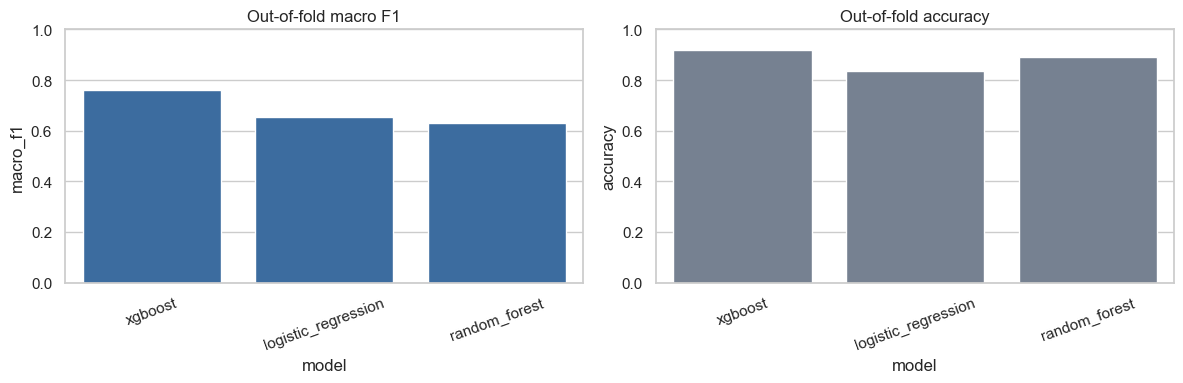

Selected XGBoost: accuracy=0.9186, macro F1=0.7596


In [14]:
comparison = pd.read_csv(ROOT / "results/model_comparison.csv")
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=comparison, x="model", y="macro_f1", ax=axes[0], color="#2b6cb0")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_title("Out-of-fold macro F1")
sns.barplot(data=comparison, x="model", y="accuracy", ax=axes[1], color="#718096")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_title("Out-of-fold accuracy")
plt.tight_layout()
plt.show()

selected = comparison.iloc[0]
assert selected["model"] == "xgboost"
print(
    f"Selected XGBoost: accuracy={selected['accuracy']:.4f}, "
    f"macro F1={selected['macro_f1']:.4f}"
)

### Per-class XGBoost results

The classification report and confusion matrix show which classes are separated well
and where errors remain. This is more informative than reporting only one aggregate
score.

,precision,recall,f1-score,support
Clutch Release,0.4444,0.3636,0.4000,11.0
Harsh Acceleration,0.8571,0.9231,0.8889,13.0
Harsh Braking,0.8889,1.0000,0.9412,16.0
Normal Driving,0.9617,0.9437,0.9526,213.0
Pothole/Bump,0.5000,0.8000,0.6154,5.0
macro avg,0.7304,0.8061,0.7596,258.0
weighted avg,0.9209,0.9186,0.9186,258.0


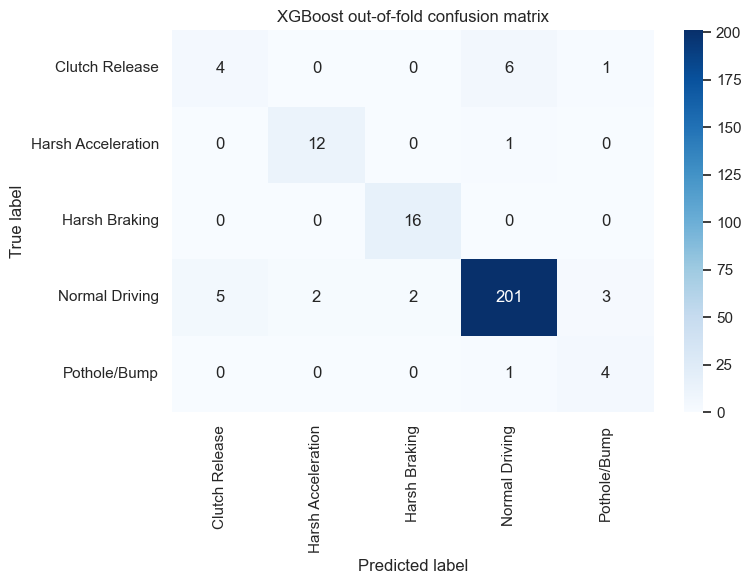

In [15]:
xgb_evaluation = model_evaluation["aggregate"]["xgboost"]
class_order = xgb_evaluation["labels"]
class_report = pd.DataFrame(xgb_evaluation["classification_report"]).T
display(class_report.loc[[*class_order, "macro avg", "weighted avg"]].round(4))

confusion = np.asarray(xgb_evaluation["confusion_matrix"], dtype=int)
assert confusion.sum() == int(class_report.loc["weighted avg", "support"])
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("XGBoost out-of-fold confusion matrix")
plt.tight_layout()
plt.show()

### Feature importance

I inspect the strongest XGBoost features to understand which time scales and sensor
statistics contribute most to the fitted model.

,feature,importance
0,negative_az_fraction_w0.25s,0.10807
1,gyro_x_dps_absmax_w0.5s,0.07749
2,accel_y_delta_g_range_w0.5s,0.07074
3,accel_z_filt_g_mean_w0.25s,0.06267
4,accel_z_filt_g_max_w0.25s,0.06135
5,accel_y_delta_g_max_w0.25s,0.05895
6,gps_speed_mps,0.05852
7,gyro_y_dps_mean_w0.5s,0.05004
8,accel_z_filt_g_min_w0.25s,0.04927
9,accel_z_filt_g_min_w0.5s,0.04861


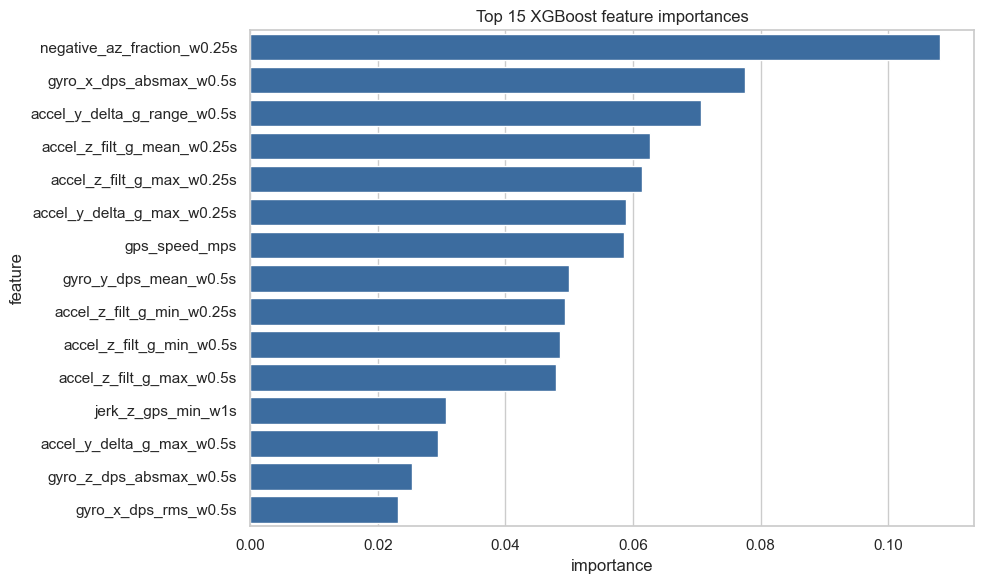

In [16]:
importance = pd.read_csv(ROOT / "results/feature_importance.csv")
assert len(importance) == 125
assert importance["importance"].ge(0).all()
top_importance = importance.head(15)
display(top_importance.round(5))
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_importance,
    y="feature",
    x="importance",
    color="#2b6cb0",
)
plt.title("Top 15 XGBoost feature importances")
plt.tight_layout()
plt.show()

### Correct interpretation

XGBoost is the strongest of the three tested models on event-grouped, out-of-fold
windows. The result supports the model choice for this assignment. It does **not**
estimate deployment performance because all reviewed intervals come from one short
session and each target class has only two physical events.

A random window split would produce a higher-looking but less credible result. A deep
sequence model is also unjustified at this data scale.

## Full-session replay

The 30-minute session has no reference labels, so I use it only to demonstrate
streaming replay and output structure. The detected intervals are not used to claim
accuracy.

### Detected events across the full drive

I summarize the number of episodes per class and plot their temporal distribution over
the complete session.

,detected_episodes
label,
Pothole/Bump,37
Harsh Acceleration,24
Harsh Braking,23
Clutch Release,5


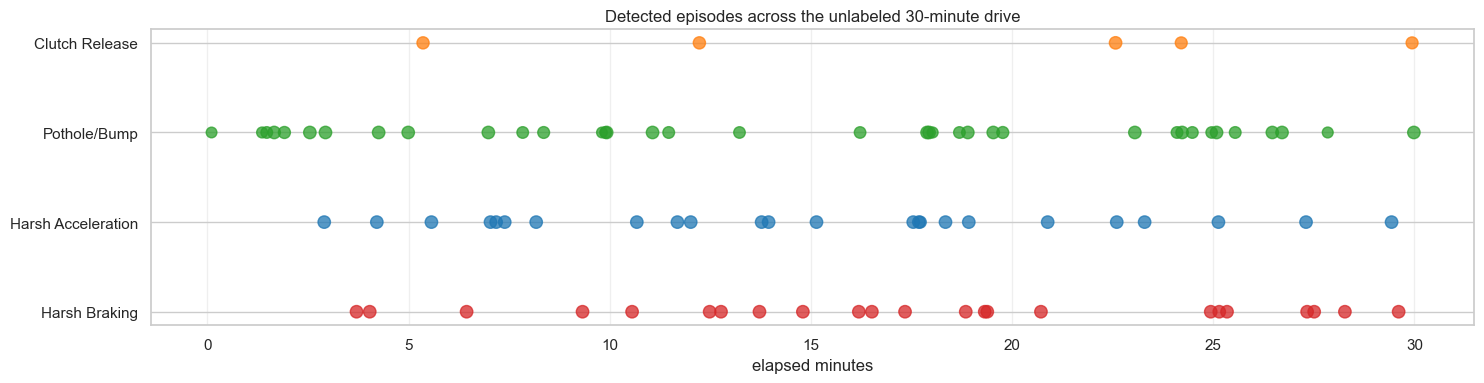

Full-session replay produced 89 de-duplicated episodes. They are inference outputs, not ground-truth accuracy evidence.


In [17]:
full_events = pd.read_csv(ROOT / "results/full_session_events.csv")
counts = (
    full_events["label"]
    .value_counts()
    .rename_axis("label")
    .to_frame("detected_episodes")
)
assert len(full_events) == summary["full_session_detection"]["detected_events"]
assert full_events["event_id"].is_unique
assert full_events["start_time_s"].between(0, full_profile["duration_s"]).all()
assert full_events["end_time_s"].between(0, full_profile["duration_s"]).all()
display(counts)

palette = {
    "Harsh Braking": "#d62728",
    "Harsh Acceleration": "#1f77b4",
    "Pothole/Bump": "#2ca02c",
    "Clutch Release": "#ff7f0e",
}
order = list(config["project"]["event_labels"])
y_position = {label: index for index, label in enumerate(order)}
plt.figure(figsize=(15, 4))
for label, part in full_events.groupby("label"):
    plt.scatter(
        part["start_time_s"] / 60,
        [y_position[label]] * len(part),
        s=30 + 50 * part["confidence"],
        alpha=0.75,
        label=label,
        color=palette[label],
    )
plt.yticks(range(len(order)), order)
plt.xlabel("elapsed minutes")
plt.title("Detected episodes across the unlabeled 30-minute drive")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
print(
    f"Full-session replay produced {len(full_events)} de-duplicated episodes. "
    "They are inference outputs, not ground-truth accuracy evidence."
)

## Reproducibility and software quality

The analysis code is implemented as reusable modules rather than duplicated across
notebook cells. I check deterministic result generation, static code quality, automated
tests, and the integrity of saved result files.

### Deterministic regeneration

I execute the pipeline a second time and compare the hashes of every generated CSV and
JSON file with the first run.

In [18]:
tracked_results = sorted(
    path
    for path in (ROOT / "results").iterdir()
    if path.is_file() and path.suffix in {".csv", ".json"}
)
hashes_before_rerun = {path.name: sha256(path) for path in tracked_results}
rerun_exit_code = execute_pipeline()
hashes_after_rerun = {path.name: sha256(path) for path in tracked_results}
determinism = pd.DataFrame(
    [
        {
            "artifact": name,
            "identical_after_clean_rerun": (
                hashes_before_rerun[name] == hashes_after_rerun[name]
            ),
        }
        for name in hashes_before_rerun
    ]
)
assert rerun_exit_code == 0
assert determinism["identical_after_clean_rerun"].all()
display(determinism)
print("The second run produced identical CSV and JSON result files")

Pipeline completed
  Labeled sample rule macro-F1: 1.0000
  Best grouped-CV model: xgboost (macro-F1=0.7596)
  Full-session detected episodes: 89
  Results: C:\Users\hp\Desktop\Sensor-Based Driving Event Detection\results


,artifact,identical_after_clean_rerun
0,feature_importance.csv,True
1,full_session_events.csv,True
2,model_comparison.csv,True
3,model_evaluation.json,True
4,sample_events.csv,True
5,summary.json,True


The second run produced identical CSV and JSON result files


### Automated checks

Ruff checks the Python source for style and common defects. Pytest covers data loading,
event matching, causal features, state-machine behavior, and streaming replay.

In [19]:
commands = {
    "Ruff": [
        sys.executable, "-m", "ruff", "check", "src", "tests",
        "driving_event_detector.py", "run_pipeline.py",
    ],
    "Pytest": [sys.executable, "-m", "pytest", "-q", "--color=no"],
}
verification_environment = {**os.environ, "NO_COLOR": "1", "PY_COLORS": "0"}
verification_rows = []
for name, command in commands.items():
    completed = subprocess.run(
        command,
        cwd=ROOT,
        text=True,
        capture_output=True,
        env=verification_environment,
    )
    output = (completed.stdout + completed.stderr).strip()
    print(f"--- {name} ---")
    print(output)
    verification_rows.append(
        {
            "check": name,
            "return_code": completed.returncode,
            "status": "PASS" if completed.returncode == 0 else "FAIL",
        }
    )
verification = pd.DataFrame(verification_rows)
assert (verification["return_code"] == 0).all()
display(verification)

--- Ruff ---
All checks passed!


--- Pytest ---
.........                                                                [100%]
9 passed in 1.47s


,check,return_code,status
0,Ruff,0,PASS
1,Pytest,0,PASS


### Result manifest

I record the path, file size, and SHA-256 hash of each compact result artifact produced
by the pipeline.

In [20]:
result_files = sorted(
    path
    for path in (ROOT / "results").iterdir()
    if path.is_file() and path.suffix in {".csv", ".json"}
)
result_manifest = pd.DataFrame(
    [
        {
            "artifact": path.relative_to(ROOT).as_posix(),
            "bytes": path.stat().st_size,
            "sha256": sha256(path),
        }
        for path in result_files
    ]
)
expected = {
    "results/feature_importance.csv",
    "results/full_session_events.csv",
    "results/model_comparison.csv",
    "results/model_evaluation.json",
    "results/sample_events.csv",
    "results/summary.json",
}
assert expected.issubset(set(result_manifest["artifact"]))
display(result_manifest)
print("All expected result artifacts are present")

,artifact,bytes,sha256
0,results/feature_importance.csv,4223,d0f0837da88dbc15a37777e68c17960aeb92b0b6b1151a...
1,results/full_session_events.csv,9285,a987dd30a3d23f14ce63dd87024445952d455e5ff8e63b...
2,results/model_comparison.csv,395,a1d8af785a060b42d2ec650315eb13df70d6192a736905...
3,results/model_evaluation.json,24041,42d9480fe706d46fe248a1f9844483353b75c5e5d5b04e...
4,results/sample_events.csv,903,a53e9fdfc9cf83bb2275936483d479259ef5cb799544de...
5,results/summary.json,6697,3aec4b812ac6b2e638581eb53c493c68d55d1e12b2c931...


All expected result artifacts are present


## Conclusion and next steps

The combined approach gives me an interpretable streaming baseline and a stronger
XGBoost model for the supplied labeled sample. XGBoost achieves 0.9186 out-of-fold
accuracy and 0.7596 macro F1 under event-grouped validation. The streaming detector
matches the eight manually identified target intervals and remains stable in the
controlled GPS-gap experiment.

The main limitation is dataset diversity. The labeled data contains one short session
and two physical examples per target class, so these results measure within-session
separability rather than generalization to new drivers, phones, mounts, or vehicles.
The 30-minute detections also require manual labels before they can be evaluated.

My next steps would be:

1. label complete trips from multiple drivers, devices, vehicles, and road conditions;
2. hold out entire trips or drivers for final testing;
3. improve orientation normalization and detect mount changes;
4. tune and calibrate XGBoost only inside grouped validation data;
5. select event thresholds using recall and false positives per driving hour;
6. collect additional Clutch Release examples and difficult Normal Driving cases;
7. compare a compact temporal CNN only after the labeled dataset is substantially larger;
8. profile latency, memory, and power consumption on the target phone.